In [1]:
%reload_ext autoreload
%autoreload 2
import os
import anndata as ad
import numpy as np 
import pandas as pd 
import seaborn as sns
from scipy import stats
import networkx as nx

import sys
import matplotlib.pyplot as plt
import scanpy as sc 
# import decoupler as dc 
# from scipy.stats import pearsonr
import json
import itertools
import warnings
from tqdm import tqdm
from scipy.sparse import csr_matrix
from sklearn.preprocessing import minmax_scale
from statsmodels.formula.api import mixedlm
from statsmodels.stats.multitest import multipletests


from src.helper import *

sys.path.insert(0, '../')
from task_grn_inference.src.utils.util import colors_blind
from task_grn_inference.src.exp_analysis.helper import Exp_analysis, plot_interactions, create_interaction_info, create_interaction_df, jaccard_similarity_net, cosine_similarity_net, calculate_feature_distance, plot_cumulative_density
from task_grn_inference.src.utils.util import basic_qc, read_gmt, quantile_transformation, zscore_transformation
from task_grn_inference.src.process_data.perturbation.normalization.script import normalize_func
from scipy.cluster.hierarchy import linkage



%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

warnings.filterwarnings("ignore")

task_grn_inference_dir = '../task_grn_inference'

par = {
    'input_dir': 'input/',
    'age_groups': ['34-', '35_44', '45_54', '55_64', '65_75']
    }

genesets_dict = get_genesets()
target_genes = np.unique(np.concatenate(list(genesets_dict.values())))

# Create a DataFrame for pathway annotations
pathway_assignments = []
for pathway, genes in genesets_dict.items():
    for gene in genes:
        pathway_assignments.append((gene, pathway))

pathway_df = pd.DataFrame(pathway_assignments, columns=['gene', 'pathway']).set_index('gene')


df = pd.read_csv('https://www.tau.ac.il/~elieis/HKG/HK_genes.txt', sep=' ', header=None)
housekeeping_genes = set(df.loc[:, 0])

def plot_biparte(df):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

    # Left plot - color by mean_x
    sc1 = ax1.scatter(
        df['bonferroni_x'], 
        df['bonferroni_y'], 
        c=df['mean_x'], 
        cmap='viridis', 
        alpha=0.7
    )
    ax1.set_title('Color by Mean X')
    ax1.set_xlabel('Bonferroni X')
    ax1.set_ylabel('Bonferroni Y')
    fig.colorbar(sc1, ax=ax1, label='Mean X expression')

    # Right plot - color by mean_y
    sc2 = ax2.scatter(
        df['bonferroni_x'], 
        df['bonferroni_y'], 
        c=df['mean_y'], 
        cmap='viridis', 
        alpha=0.7
    )
    ax2.set_title('Color by Mean Y')
    ax2.set_xlabel('Bonferroni X')
    fig.colorbar(sc2, ax=ax2, label='Mean Y expression')

    # Display the plots
    plt.tight_layout()
    plt.show()

In [42]:
df_base = pd.read_csv('output/links_pvalues_vs_34_sla_pearson_False.csv', index_col=0)
df_dn = pd.read_csv('output/links_pvalues_vs_34_sla_pearson_True.csv', index_col=0)

In [54]:
for df in [df_base, df_dn]:
    df['bonferroni'] = multipletests(df['pvalue'], alpha=0.05, method='bonferroni')[1]
    df['fdr'] = multipletests(df['pvalue'], alpha=0.05, method='fdr_bh')[1]
    print('\n ', 'links: ', len(df), '-- FDRn: ', (df['fdr']<0.05).sum(), ' -- BFn: ', (df['bonferroni']<0.05).sum())


  links:  1386112 -- FDRn:  8374  -- BFn:  149

  links:  1386112 -- FDRn:  23263  -- BFn:  259


count of links in the base and absent in the dc:  46


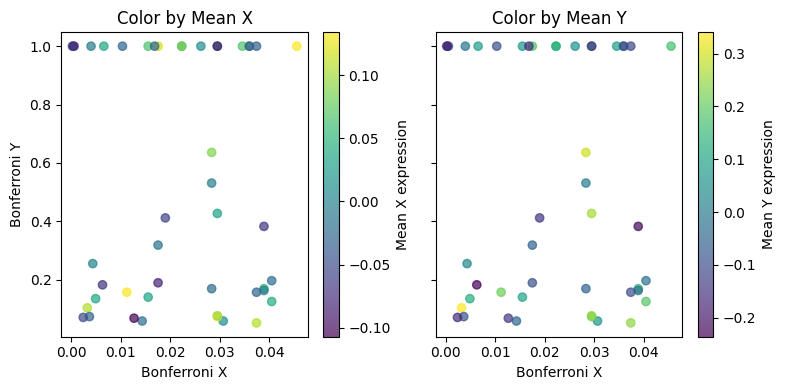

In [89]:
# - check which links are in the base and not dn 
df_merge = df_base.merge(df_dn, on=['link', 'age_group'], how='left')
df_sig_left = df_merge[df_merge['bonferroni_x']<0.05]
df_sig_absent = df_sig_left[df_sig_left['bonferroni_y']>0.05]

print('count of links in the base and absent in the dc: ', len(df_sig_absent))

plot_biparte(df_sig_absent)


count of links in the base and absent in the dc:  156


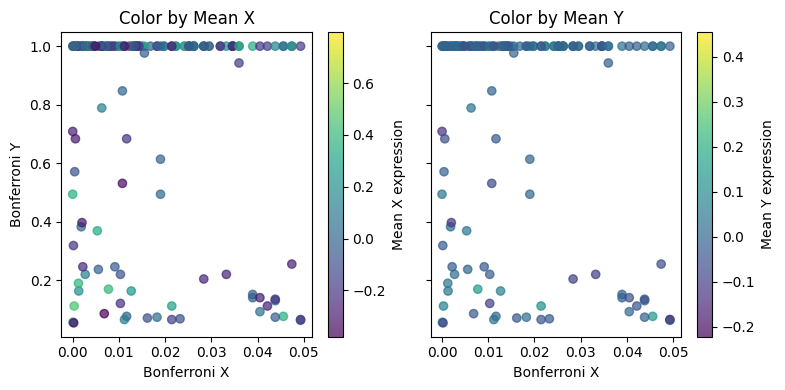

In [90]:
# - check which links are in the dn and not base 
df_merge = df_dn.merge(df_base, on=['link', 'age_group'], how='left')
df_sig_left = df_merge[df_merge['bonferroni_x']<0.05]
df_sig_absent = df_sig_left[df_sig_left['bonferroni_y']>0.05]

print('count of links in the base and absent in the dc: ', len(df_sig_absent))

plot_biparte(df_sig_absent)

# Evaluate corr

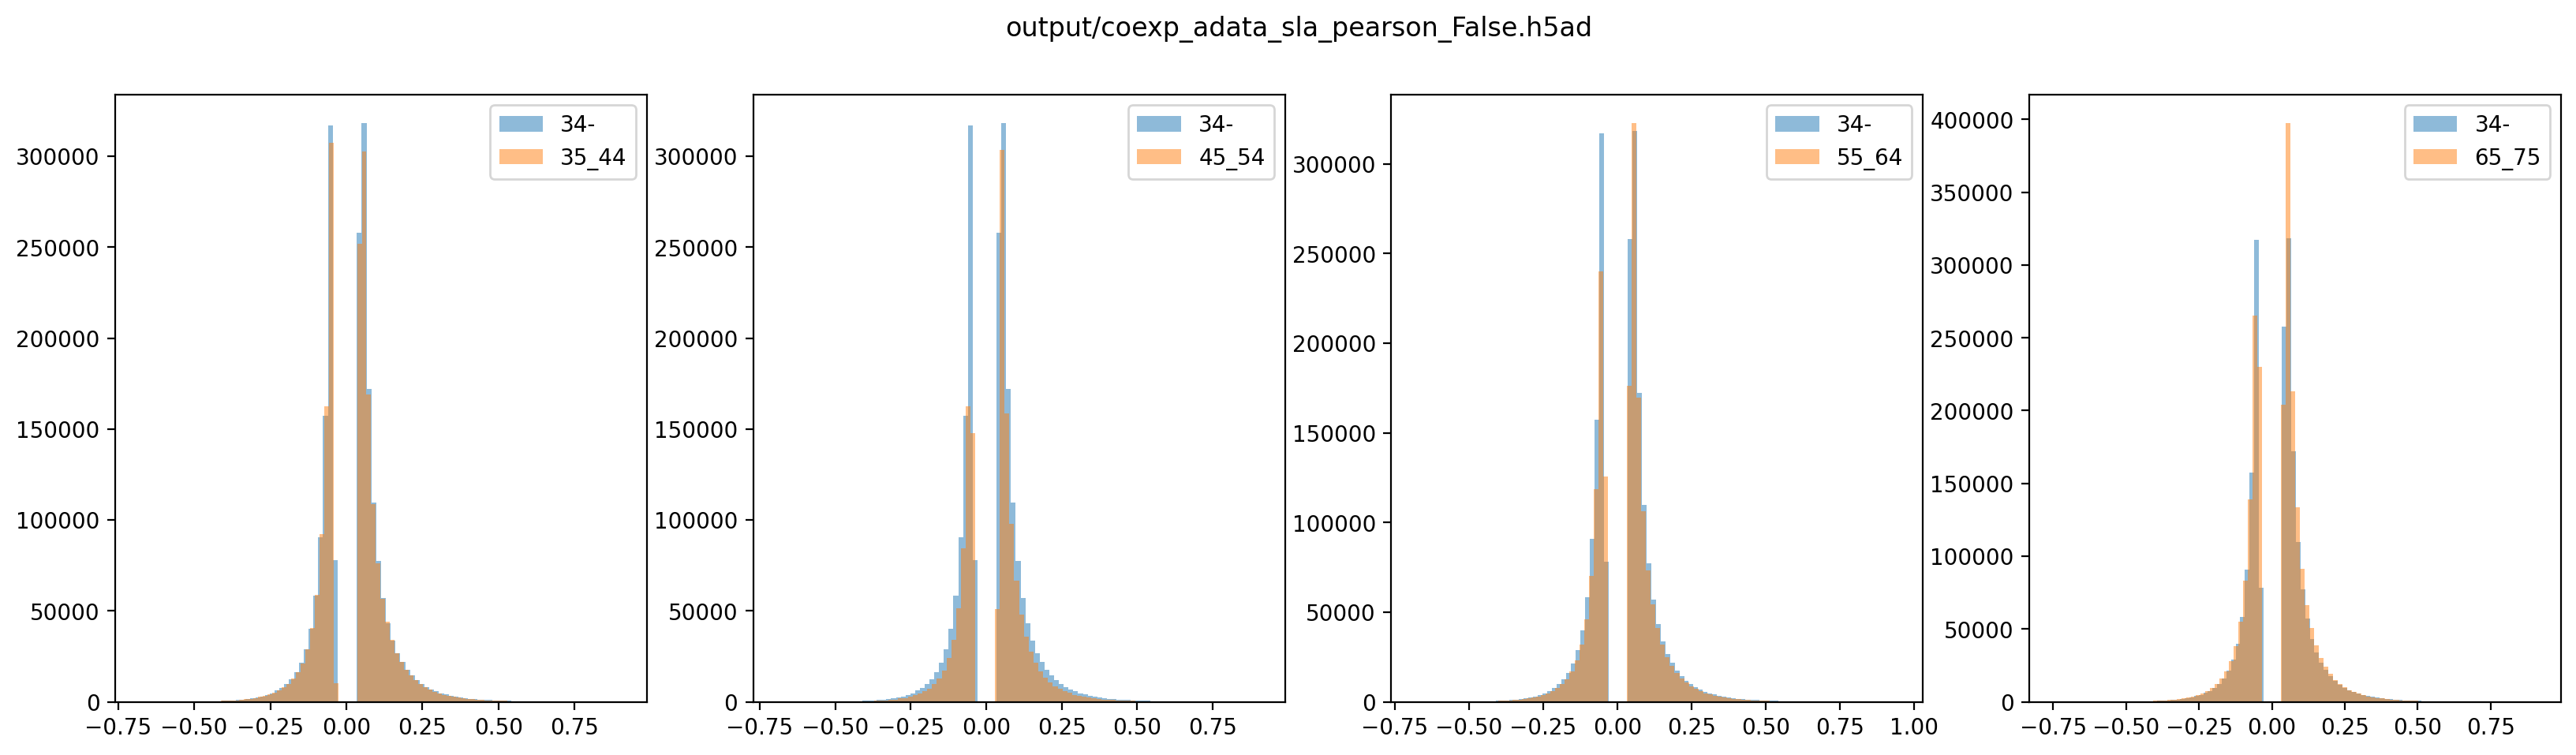

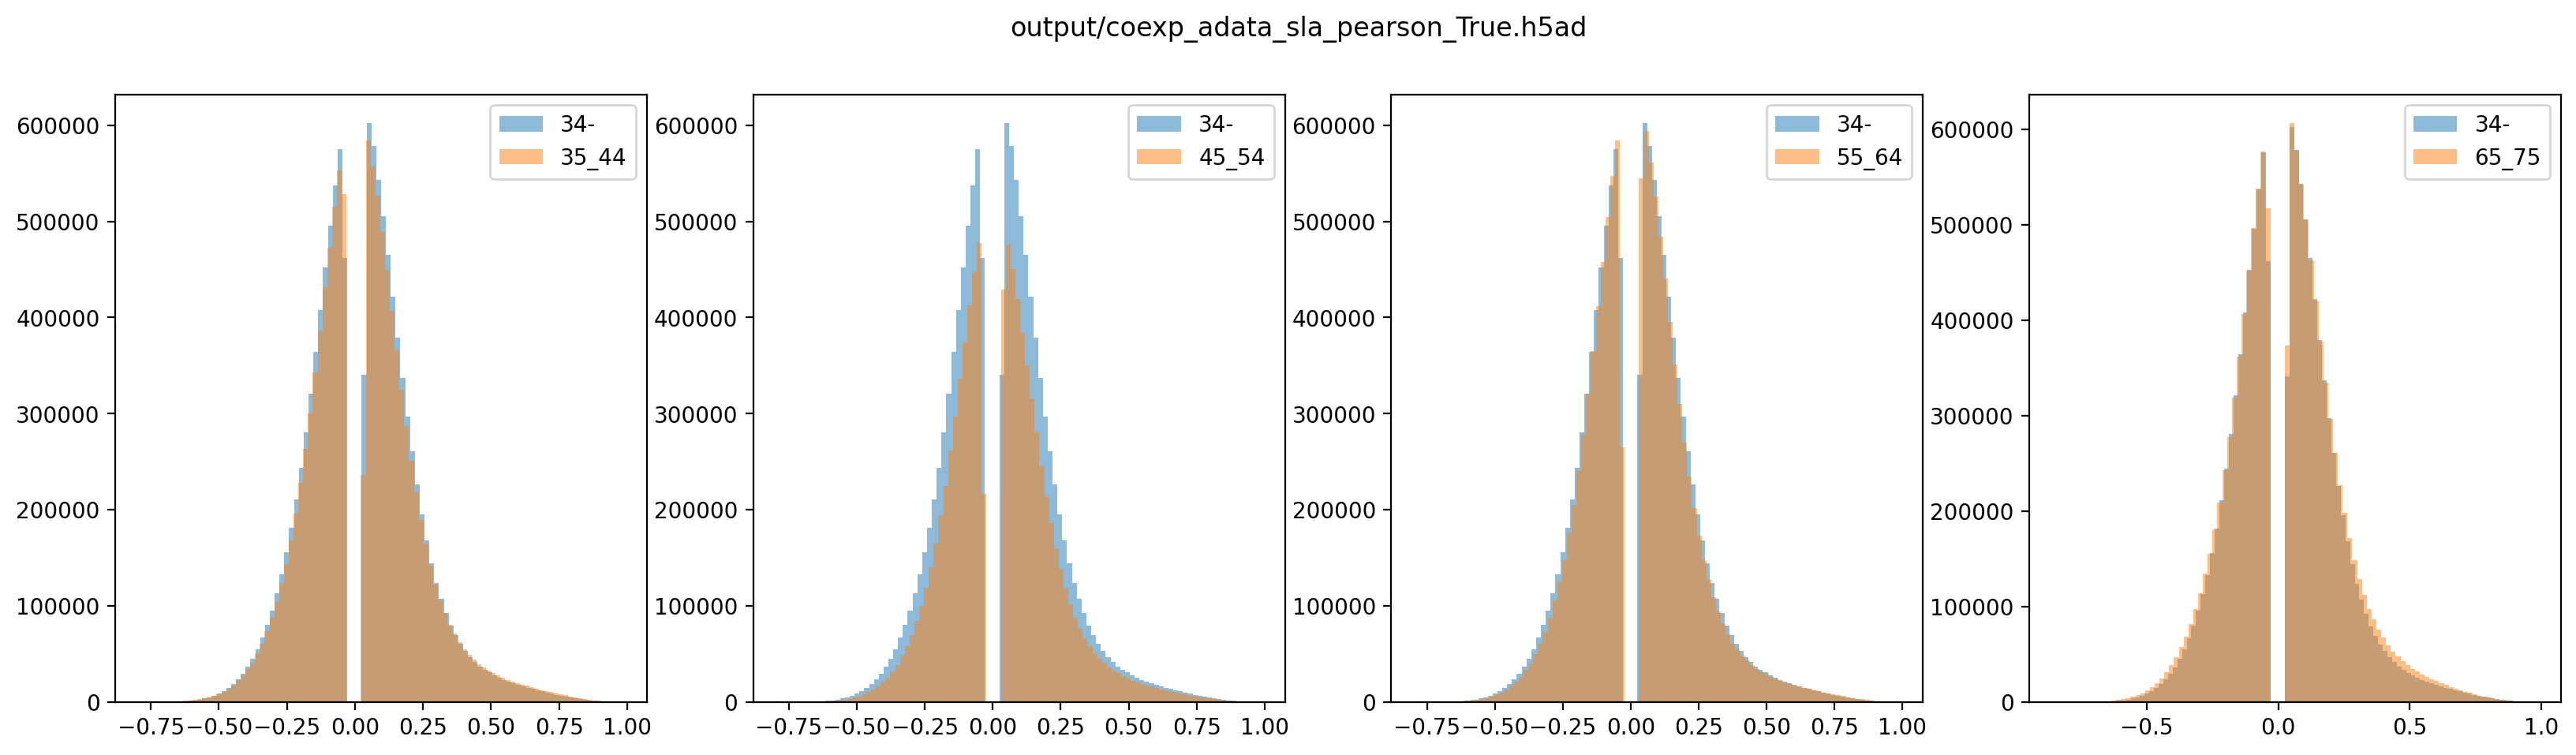

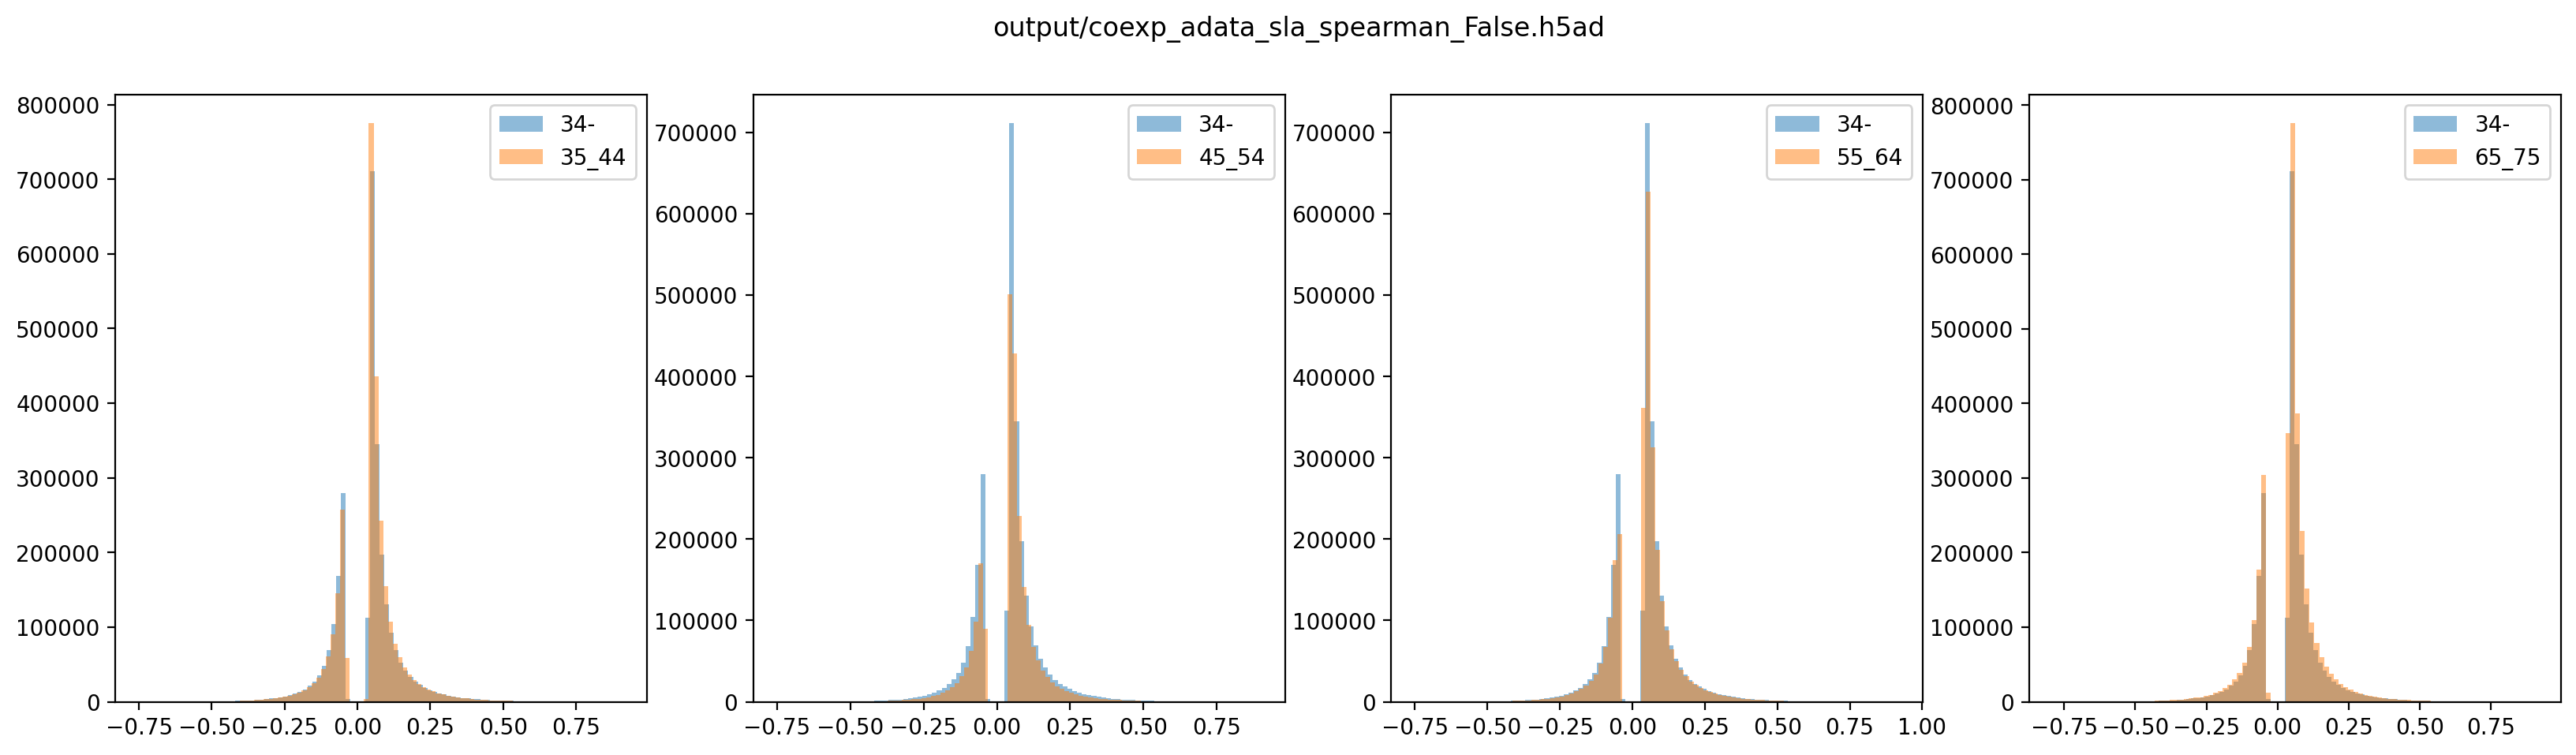

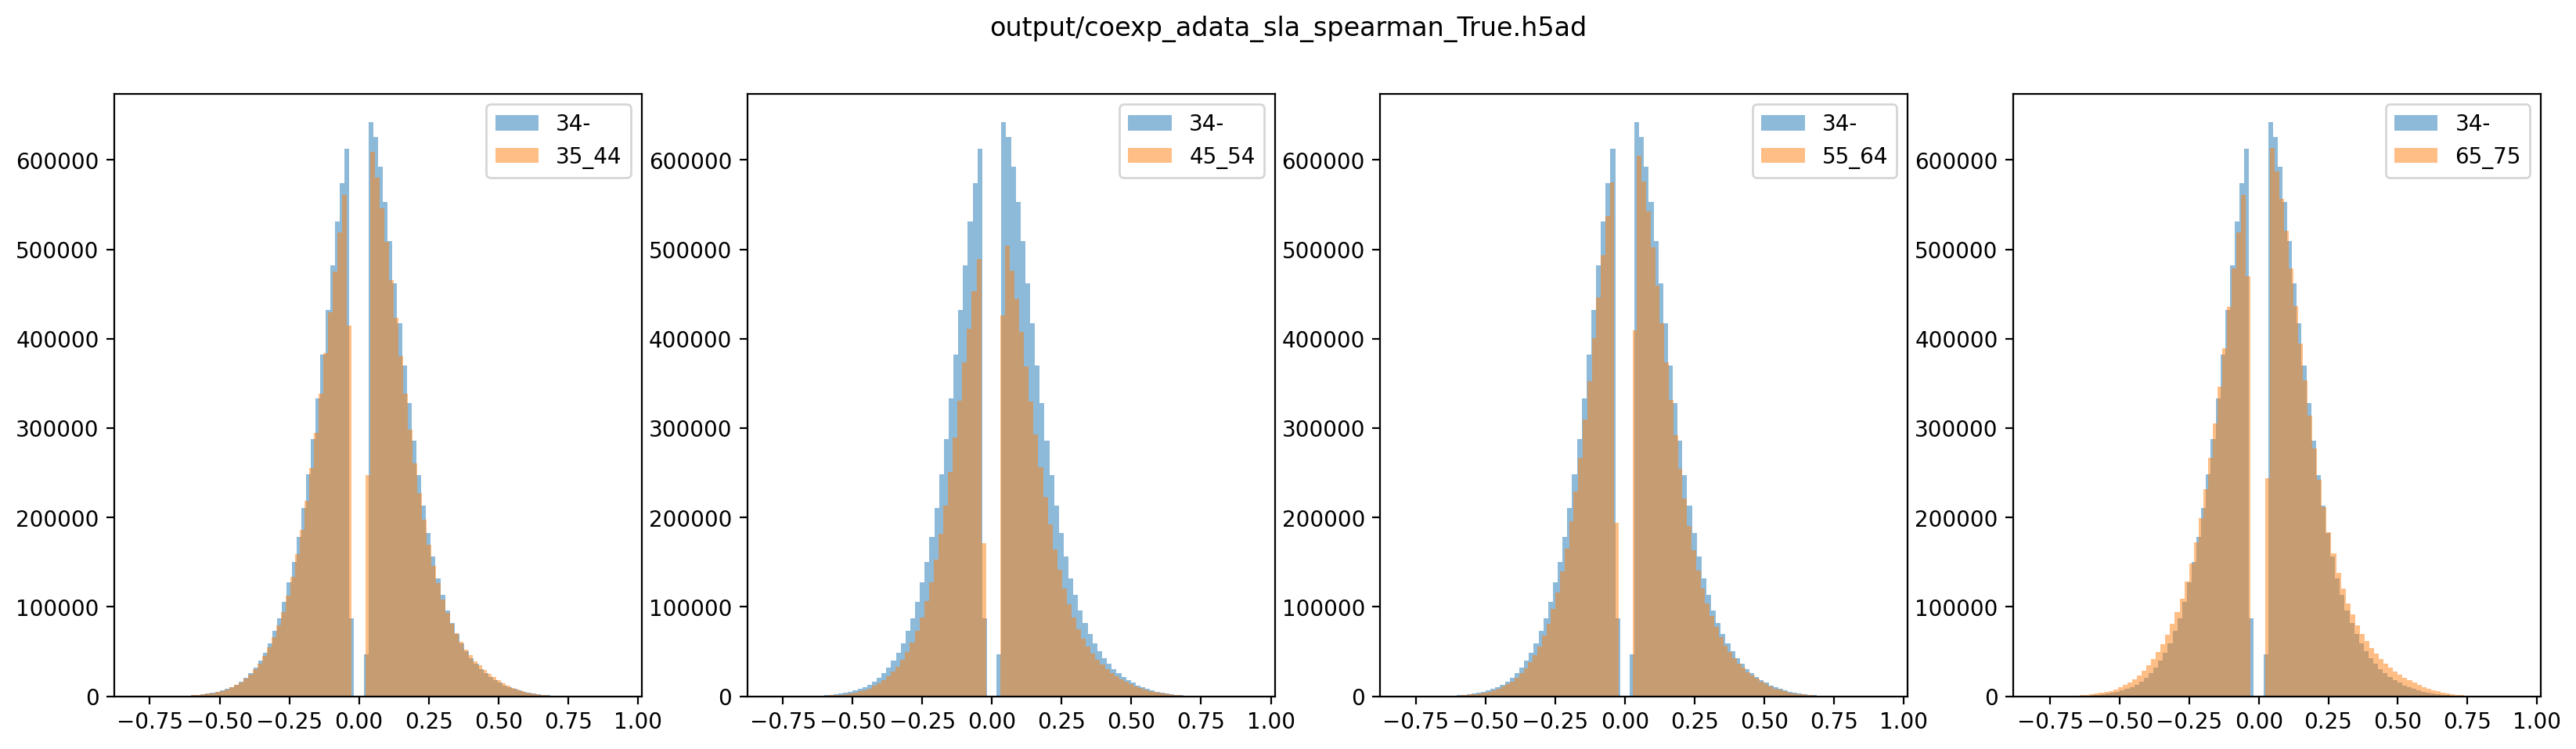

In [62]:
for file in [
            'output/coexp_adata_sla_pearson_False.h5ad', 'output/coexp_adata_sla_pearson_True.h5ad','output/coexp_adata_sla_spearman_False.h5ad',
            'output/coexp_adata_sla_spearman_True.h5ad']:
    coexp_adata = ad.read_h5ad(file)

    fig, axes = plt.subplots(1, 4, figsize=(20,5))

    ax = axes[0]
    for age_group in ['34-', '35_44']:
        mask = coexp_adata.obs.age_group==age_group
        data = coexp_adata[mask,:].X.flatten()
        data = data[data!=0]
        ax.hist(data, label=age_group, bins=100, alpha=.5)
    ax.legend()

    ax = axes[1]
    for age_group in ['34-', '45_54']:
        mask = coexp_adata.obs.age_group==age_group
        data = coexp_adata[mask,:].X.flatten()
        data = data[data!=0]
        ax.hist(data, label=age_group, bins=100, alpha=.5)
    ax.legend()

    ax = axes[2]
    for age_group in ['34-', '55_64']:
        mask = coexp_adata.obs.age_group==age_group
        data = coexp_adata[mask,:].X.flatten()
        data = data[data!=0]
        ax.hist(data, label=age_group, bins=100, alpha=.5)
    ax.legend()

    ax = axes[3]
    for age_group in ['34-', '65_75']:
        mask = coexp_adata.obs.age_group==age_group
        data = coexp_adata[mask,:].X.flatten()
        data = data[data!=0]
        ax.hist(data, label=age_group, bins=100, alpha=.5)
    ax.legend()
    fig.suptitle(file)

In [63]:
aaaa

NameError: name 'aaaa' is not defined

In [2]:
adata_dir='input/adata.h5ad'
corr_method='spearman'
targeted=True
    
genesets = get_genesets()
target_genes = np.unique(np.concatenate(list(genesets.values())))

adata_all = ad.read_h5ad(adata_dir) 
if targeted:
    adata_all = adata_all[:, adata_all.var_names.isin(target_genes)]

In [8]:
group='age_donor'
normalize='apr'
denoise=True


i_all = 0
for i, age_group in enumerate(adata_all.obs.age_group.unique()):
    adata_age_group= adata_all[adata_all.obs.age_group==age_group]

    adata = adata_age_group
    
    for i_donor, age_donor in enumerate(tqdm(adata.obs[group].unique())):
        adata_age = adata[adata.obs[group].eq(age_donor), :]

        adata_age = basic_qc(adata_age, min_cells_per_gene=10, min_genes_per_cell=10)

        if normalize=='sla': 
            print(normalize)
            sc.pp.normalize_total(adata_age)
            sc.pp.log1p(adata_age)
        elif normalize=='apr':
            sc.experimental.pp.normalize_pearson_residuals(adata_age)
        
        X_subset = adata_age.X
        try:
            X_subset = X_subset.todense().A
        except:
            X_subset = X_subset
        
        if denoise:
            X_subset = denoise_func(X_subset)
            # corr_matrix = corr_latent_space(X_subset, n_components=100)
        # else:
        if corr_method=='pearson':
            # corr_matrix = np.corrcoef(X_subset.T)
            corr_matrix, p_values = fast_pearson_with_pvalues(X_subset)
        elif corr_method=='spearman':
            from scipy.stats import spearmanr
            corr_matrix, p_values = spearmanr(X_subset, nan_policy='raise')
        
        # correct the p value
        p_values_flat = p_values.flatten()
        _, p_values_corrected_flat, _, _ = multipletests(p_values_flat, method='fdr_bh')
        p_values_corrected = p_values_corrected_flat.reshape(p_values.shape)

        mask_non_sig =  p_values_corrected>=0.05
        corr_matrix[mask_non_sig] = 0

        aaaa

  0%|          | 0/30 [00:00<?, ?it/s]

shape before  (4070, 867)
shape after  (4070, 862)


  0%|          | 0/30 [00:09<?, ?it/s]


NameError: name 'aaaa' is not defined

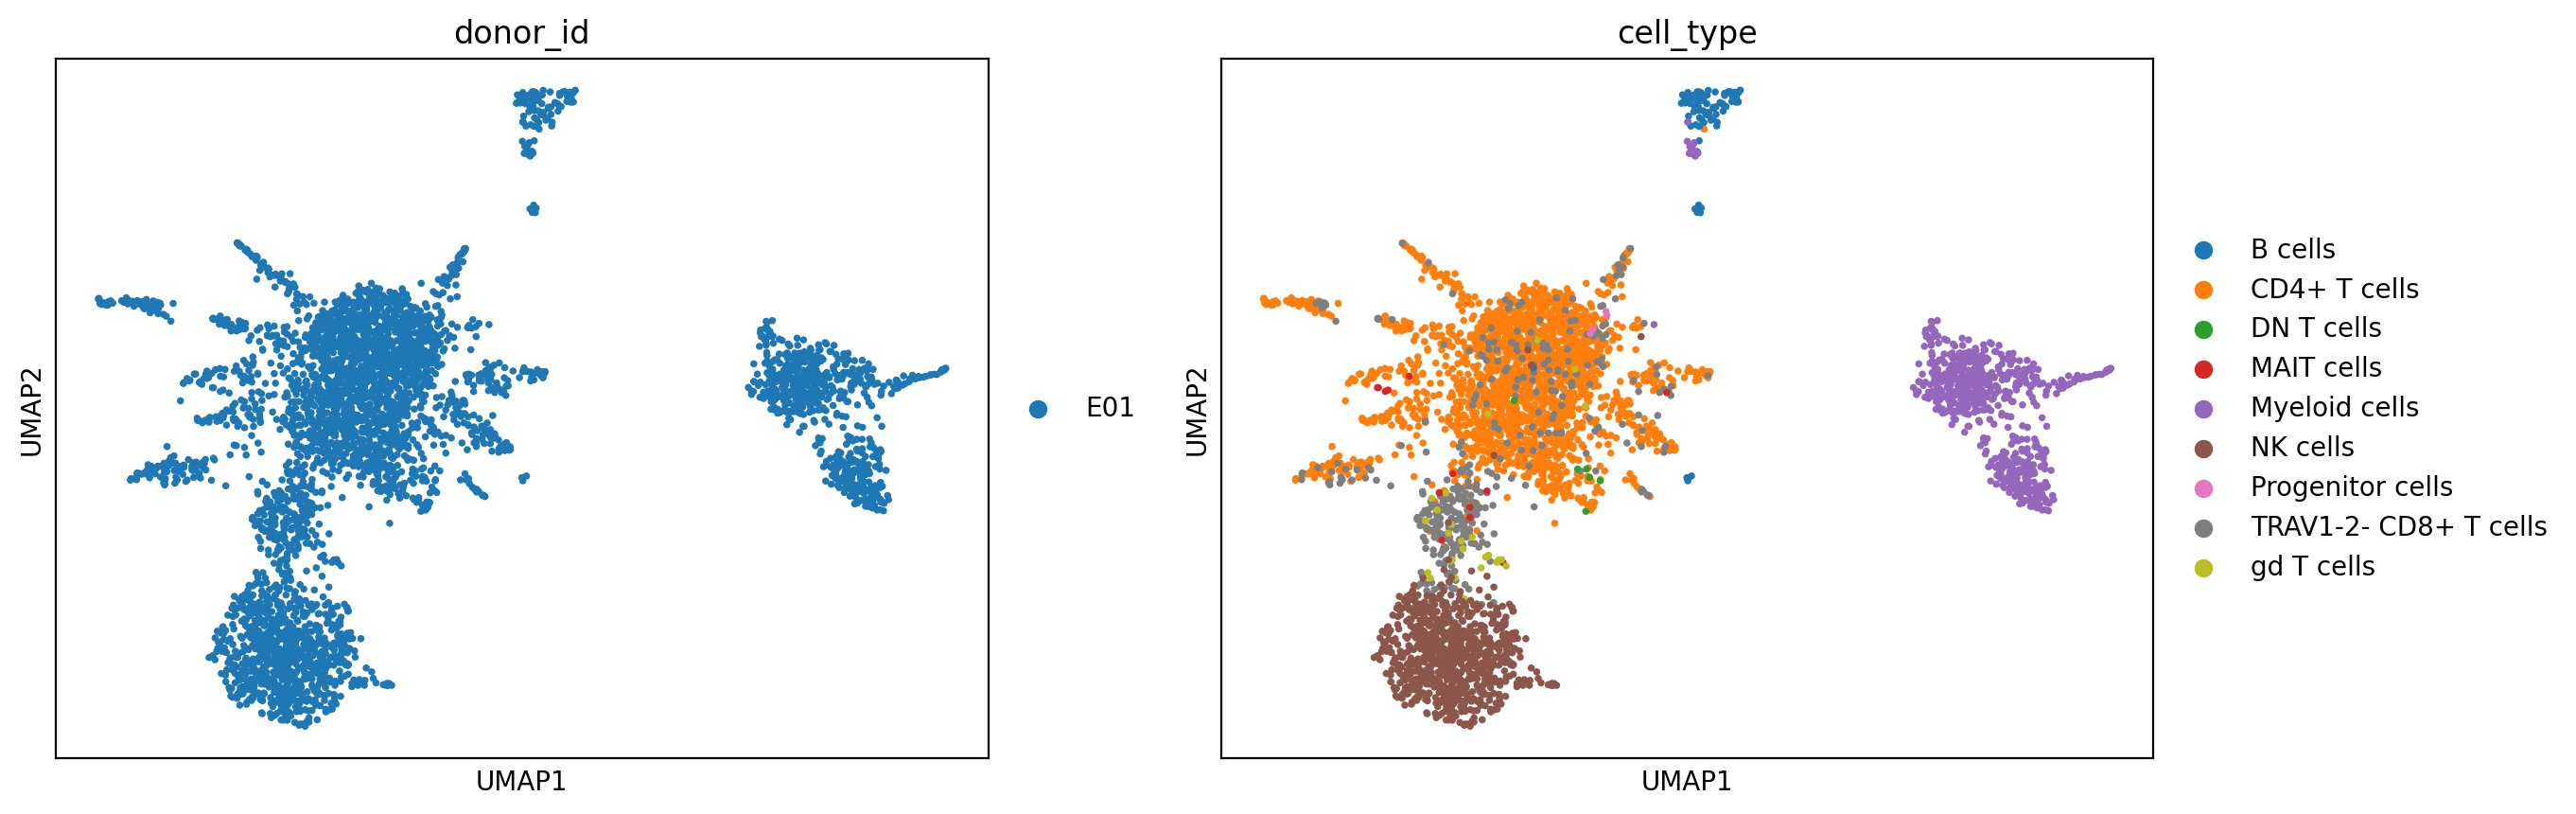

In [9]:
sc.pp.neighbors(adata_age)
sc.tl.umap(adata_age)
sc.pl.umap(adata_age, color=['donor_id', 'cell_type'])

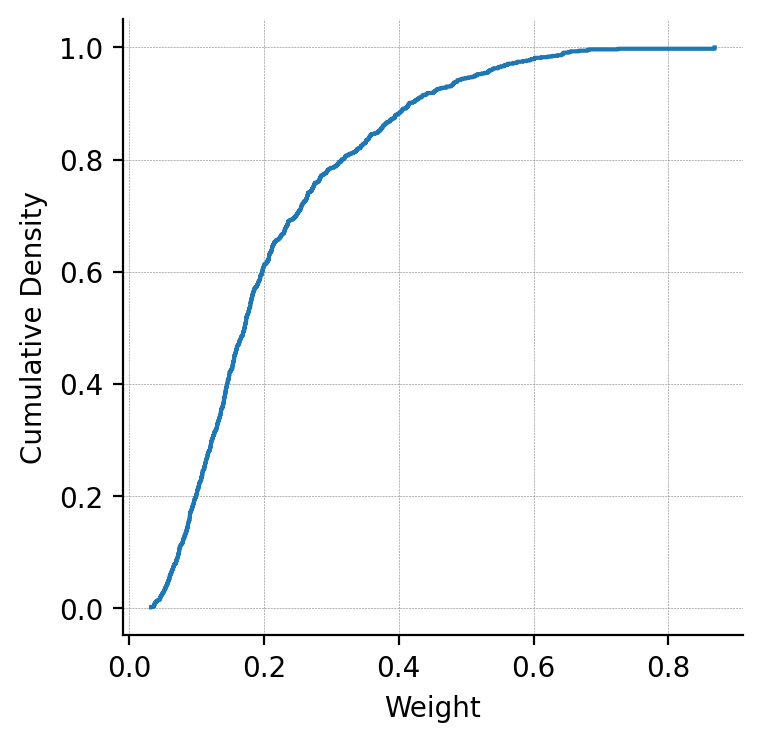

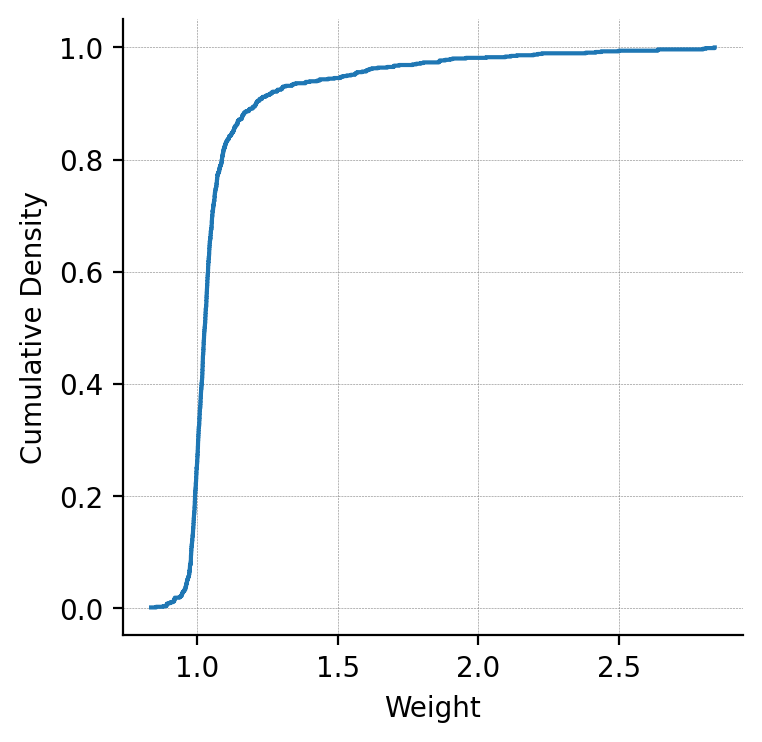

In [31]:
aa = plot_cumulative_density(adata_age_sla.X.todense().A.std(axis=0))
aa = plot_cumulative_density(adata_age.X.std(axis=0))

In [32]:
(p_values_corrected.flatten()<0.05).sum()/p_values.flatten().size

0.7301747944940004

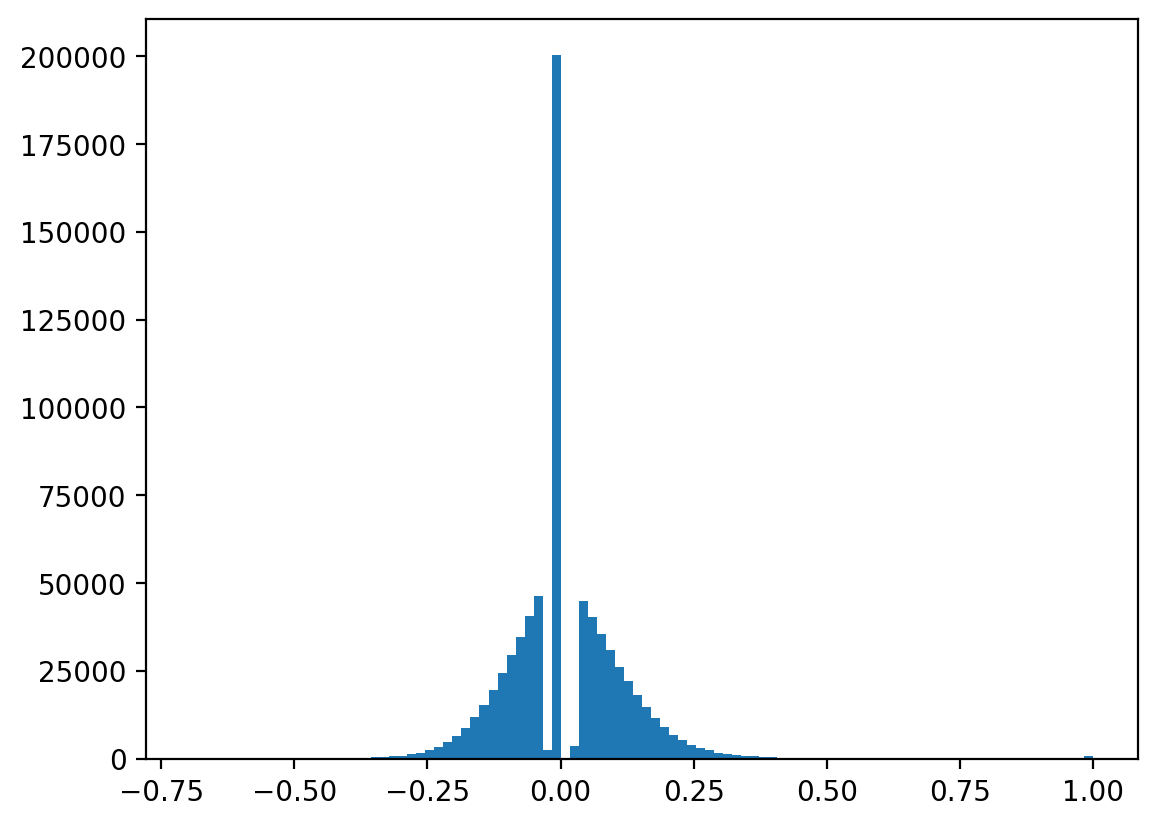

In [33]:
import matplotlib as mpl

# Set chunksize to a value that limits path complexity
mpl.rcParams['agg.path.chunksize'] = 10000  # Adjust this value as needed

# aa = plt.hist(p_values.flatten(), bins=100)
# plot_cumulative_density(p_values.flatten())
aa = plt.hist(corr_matrix.flatten(), bins=100)

In [47]:
adata_all = ad.read_h5ad(adata_dir) 

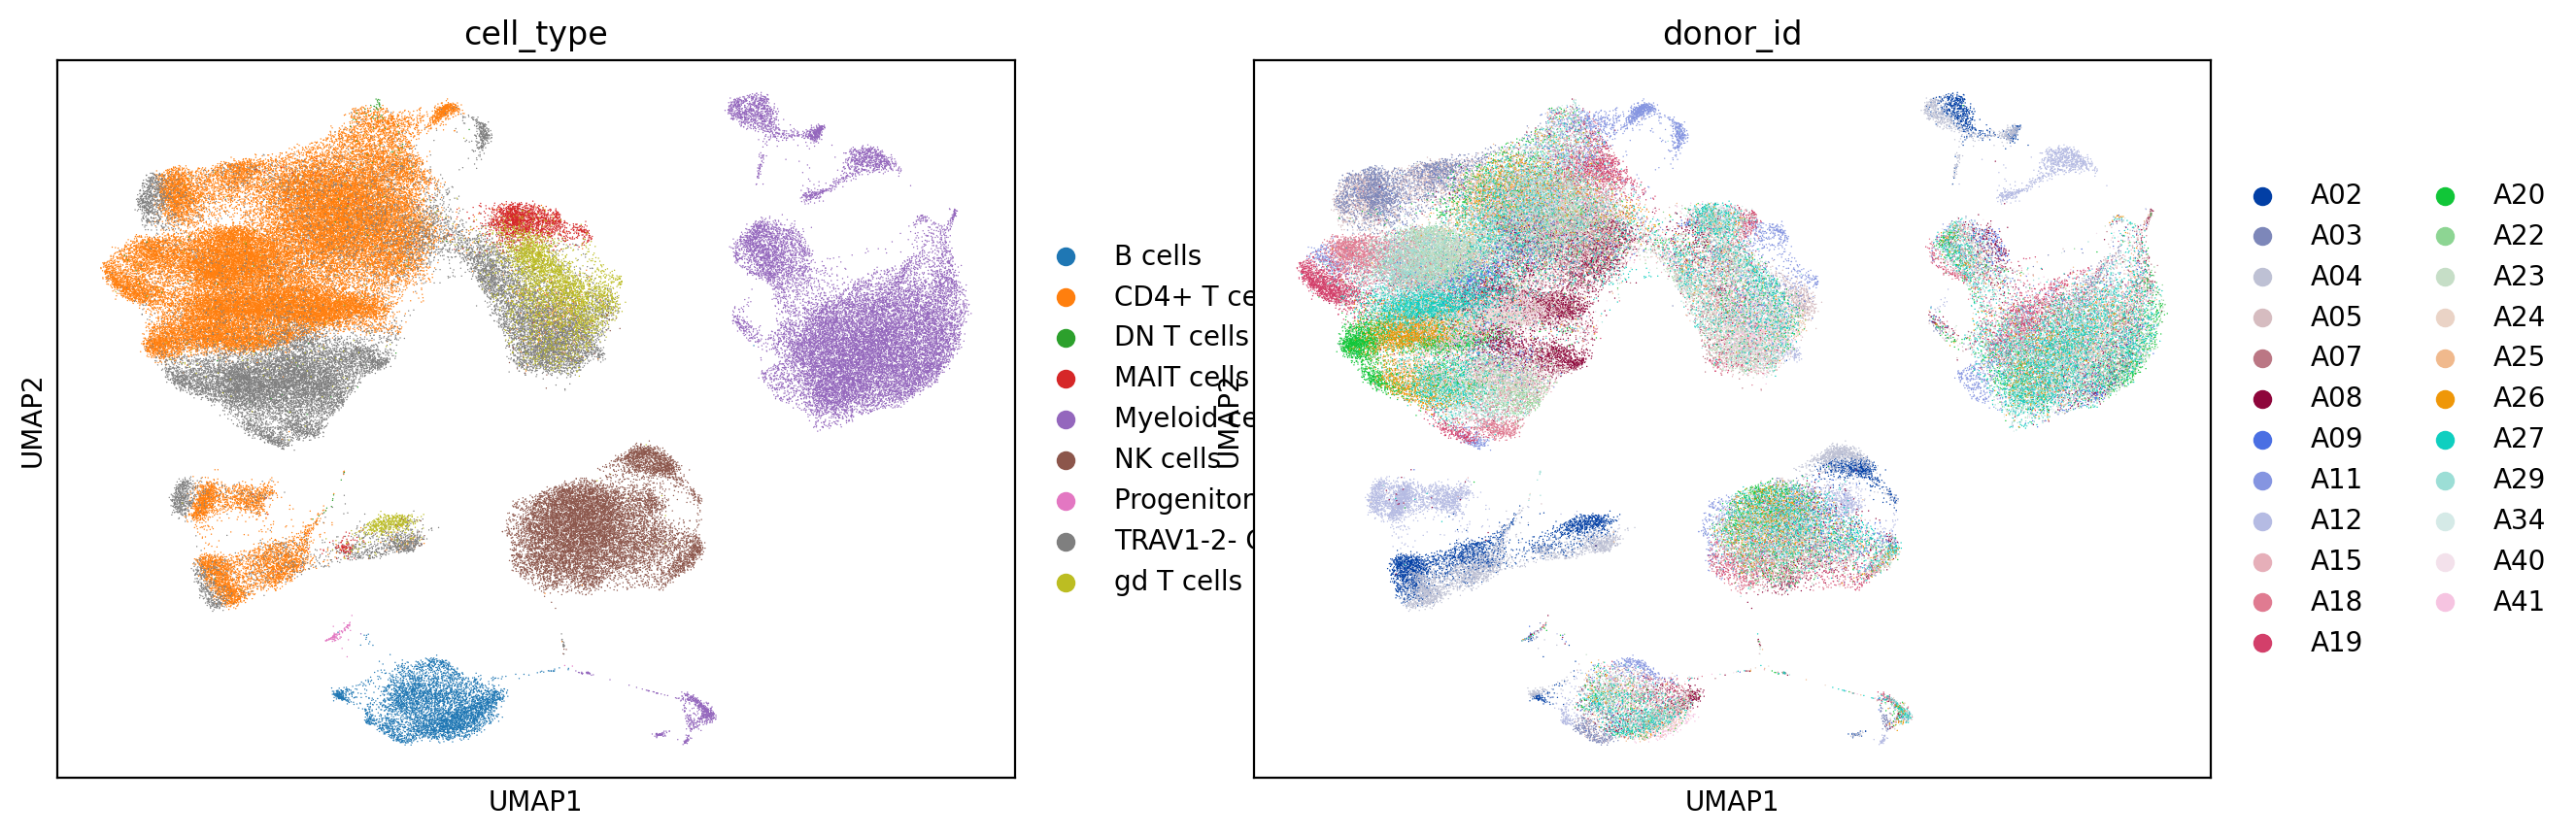

In [48]:
adata = adata_all[adata_all.obs.age_group=='34-']
# - umap 
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color=['cell_type', 'donor_id'])

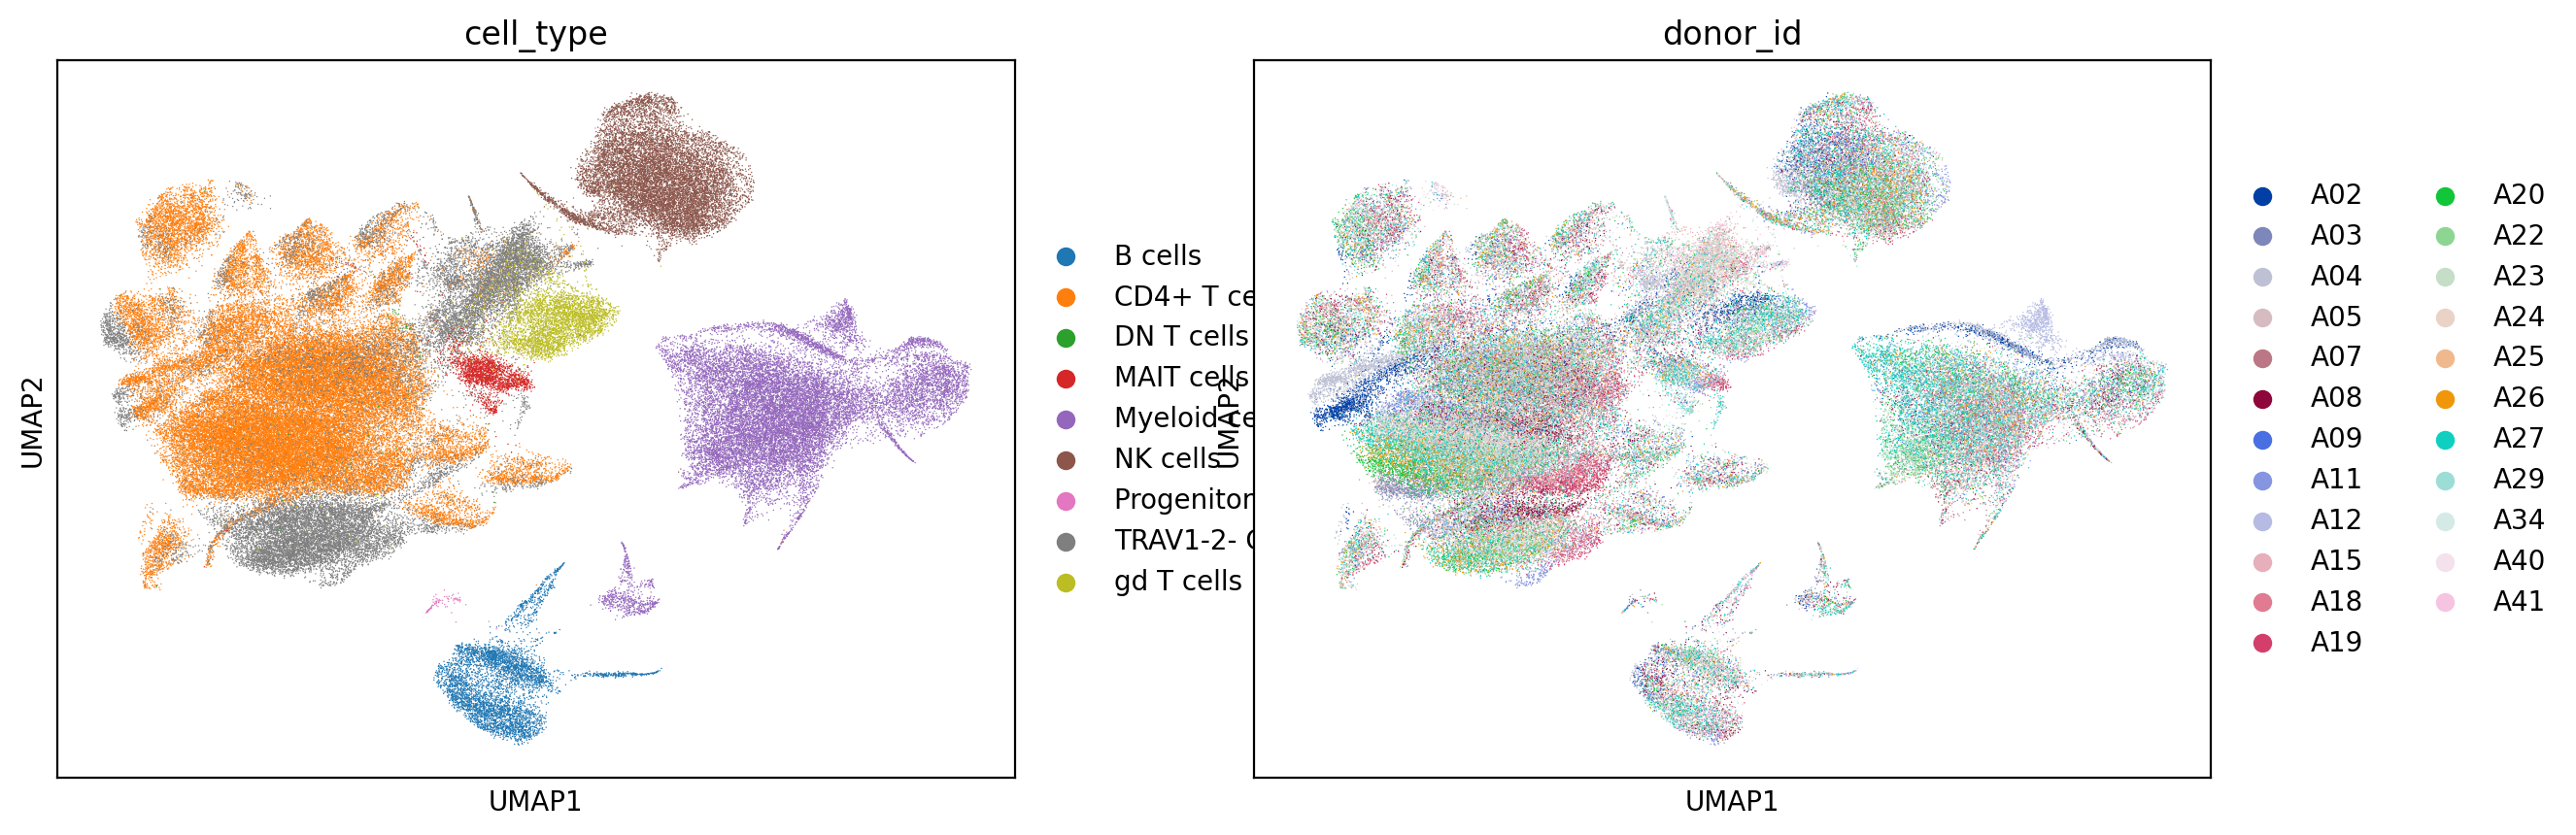

In [61]:
adata = adata_all[adata_all.obs.age_group=='34-']
# - umap 
sc.experimental.pp.normalize_pearson_residuals(adata)

sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color=['cell_type', 'donor_id'])